# Vast.ai / арендованный GPU (RTX 5090)

**Структура перед запуском:**
```
рабочая_папка/
├── kazakh_missing_words_vastai.ipynb
└── data/
    ├── train.csv
    └── test_inputs.csv
```

**Оптимизации:** batch_size=64 под 32GB VRAM, eval_strategy (новый API transformers).

# Vast.ai / арендованный GPU (RTX 5090, 32 GB)

**Структура:** создай папку `data/` рядом с ноутбуком, положи в неё:
- `train.csv`
- `test_inputs.csv`

**Изменения:** batch_size=64 (под 32 GB VRAM), eval_strategy вместо evaluation_strategy.

# Kazakh Missing Words Challenge — WISH Hackathon 2026

**Задача:** предсказать 0-based индекс позиции пропущенного слова в казахском предложении.

**Модель:** XLM-RoBERTa-base (sequence classification, num_labels = max_position).

In [2]:
# Vast.ai: установка в тот же Python, что и Jupyter kernel
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numpy", "pandas", "matplotlib", "scikit-learn", "torch", "transformers", "accelerate", "tqdm"], check=True)
print("Готово. Kernel → Restart, затем Run All.")

Готово. Kernel → Restart, затем Run All.


In [3]:
import numpy as np
import pandas as pd
import os

# На Kaggle — показывает файлы датасета; локально/Colab — пропускаем
if os.path.exists('/kaggle/input'):
    for dirname, _, filenames in os.walk('/kaggle/input'):
        for filename in filenames:
            print(os.path.join(dirname, filename))
else:
    print("Локальная среда: ожидаются данные в ./data/")

Локальная среда: ожидаются данные в ./data/


In [ ]:
# ⚠️ Kaggle: ЭТУ ЯЧЕЙКУ НЕ ТРОГАТЬ! transformers/accelerate уже установлены.
# pip install только ломает всё. На Kaggle — просто Run All без этой ячейки, или она пропустит pip.
if not os.path.exists("/kaggle/input"):
    get_ipython().run_cell_magic("capture", "", "!pip install -q transformers accelerate")
else:
    print("Kaggle: используем предустановленные transformers/accelerate — всё ок")

## Дополнительные импорты

Импортируем библиотеки для работы с PyTorch, transformers и sklearn.

In [ ]:
import time, random, warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer, TrainingArguments,
    DataCollatorWithPadding,
    set_seed,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tqdm.auto import tqdm

print(f"PyTorch: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

## Конфиг

Все гиперпараметры и пути в одном словаре. Пути соответствуют Kaggle dataset.

In [6]:
# Автоопределение путей: Kaggle vs локально/Colab
_data_dir = None
if os.path.exists("/kaggle/input"):
    for root, _, files in os.walk("/kaggle/input"):
        if "train.csv" in files and "test_inputs.csv" in files:
            _data_dir = root
            break
if _data_dir:
    _output_dir = "/kaggle/working"
    print("Среда: Kaggle")
    print("Данные:", _data_dir)
else:
    _data_dir = "./data"
    _output_dir = "./output"
    os.makedirs(_data_dir, exist_ok=True)
    os.makedirs(_output_dir, exist_ok=True)
    print("Среда: локально/Colab. Данные из папки data/")

_seed, _ensemble_seed = 42, 123
CFG = {
    "model_name": "xlm-roberta-large",
    "max_len": 128,
    "max_position": 55,
    "batch_size": 32,
    "epochs": 4,
    "lr": 2e-5,
    "warmup_ratio": 0.1,
    "weight_decay": 0.01,
    "fp16": True,
    "n_samples_per_sentence": 5,
    "val_size": 0.05,
    "min_words": 3,
    "seed": _seed,
    "ensemble_seeds": [_seed, _ensemble_seed],
    "use_ensemble": True,
    "train_path": os.path.join(_data_dir, "train.csv"),
    "test_path": os.path.join(_data_dir, "test_inputs.csv"),
    "output_dir": os.path.join(_output_dir, "model_seed" + str(_seed)),
    "submission_path": os.path.join(_output_dir, "submission.csv"),
    "ensemble_submission_path": os.path.join(_output_dir, "submission_ensemble.csv"),
}
set_seed(CFG["seed"])
torch.manual_seed(CFG["seed"])
print("Config ready. Seeds для ансамбля:", CFG["ensemble_seeds"])

Среда: локально/Colab. Данные из папки data/
Config ready. Seeds для ансамбля: [42, 123]


## Загрузка данных и EDA

Загружаем train и test, смотрим структуру, добавляем колонку длины предложений, строим гистограммы и обновляем `max_position`.

Train head:
                                           full_text
0  бүгін мәжіліс депутаттары осы туралы келісімді...
1                         өте ыңғайлы ризамыз шексіз
2  атап айтқанда философ еркіндіктегі себептілік ...

Test head:
   ID                                               text
0   0                     көңіл көзін сөз ашар кір басар
1   1  кук аралдары жаңа еркін ассоциация құрған поли...
2   2  арсының ақыны мағжанның рәміздік ізденістері х...


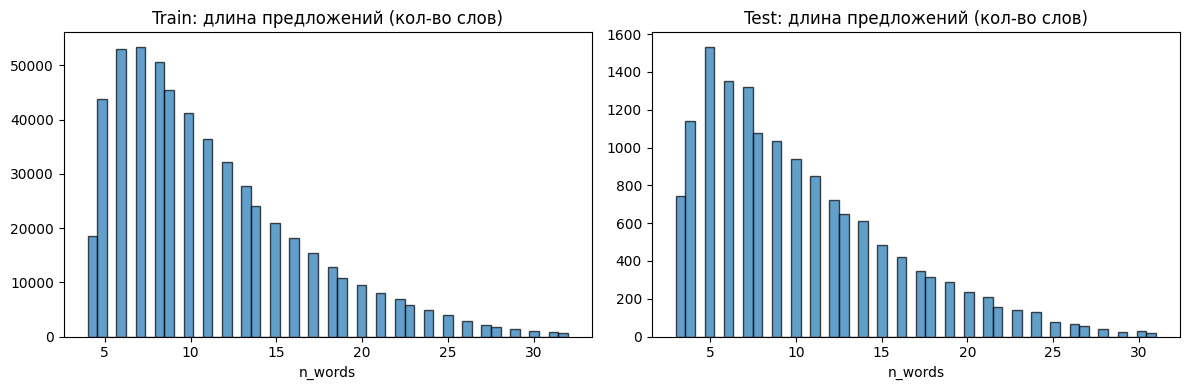

Train - max: 32, median: 10.0
Test - max: 31, median: 9.0

Обновлённый max_position: 33


In [7]:
# Загрузка или fallback на синтетические данные
if os.path.exists(CFG["train_path"]) and os.path.exists(CFG["test_path"]):
    train_df = pd.read_csv(CFG["train_path"])
    test_df = pd.read_csv(CFG["test_path"])
else:
    print("⚠️ Файлы train.csv и test_inputs.csv не найдены. Используем синтетические данные для проверки пайплайна.")
    print("   Скачай датасет с Kaggle и положи в папку data/ для реального обучения.\n")
    # Минимальный синтетический датасет (примеры на казахском)
    _sentences = [
        "Мен дүкенге барып келдім", "Сәлем қалайсың", "Бүгін жақсы күн",
        "Ол мектепке барды", "Біз кітап оқыдық", "Сен қайда бардың",
        "Мен үйдемін", "Олар кино көрді", "Бүгін салқын ауа",
        "Ол жақсы оқушы", "Мен спортты жақсы көремін",
    ] * 500  # ~5500 предложений для быстрого прогона
    train_df = pd.DataFrame({"full_text": _sentences})
    test_df = pd.DataFrame({
        "ID": range(100),
        "text": ["Мен барып келдім", "Сәлем қалайсың", "Бүгін жақсы"] * 33 + ["Мен барып келдім"],
    })

print("Train head:")
print(train_df.head(3))
print("\nTest head:")
print(test_df.head(3))

if len(train_df) < 500_000:
    print(f"\n⚠️ Используется неполный датасет ({len(train_df):,} строк). Для лучшего результата загрузи полный train.csv (~554k строк).")

train_df["n_words"] = train_df["full_text"].str.split().str.len()
test_df["n_words"] = test_df["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_df["n_words"], bins=50, edgecolor="black", alpha=0.7)
axes[0].set_title("Train: длина предложений (кол-во слов)")
axes[0].set_xlabel("n_words")
axes[1].hist(test_df["n_words"], bins=50, edgecolor="black", alpha=0.7)
axes[1].set_title("Test: длина предложений (кол-во слов)")
axes[1].set_xlabel("n_words")
plt.tight_layout()
plt.show()

print(f"Train - max: {train_df['n_words'].max()}, median: {train_df['n_words'].median()}")
print(f"Test - max: {test_df['n_words'].max()}, median: {test_df['n_words'].median()}")

CFG["max_position"] = int(test_df["n_words"].max()) + 2
print(f"\nОбновлённый max_position: {CFG['max_position']}")

## Генерация обучающих данных

Из ~550k полных казахских предложений генерируем ~1.65 млн пар (текст с пропуском → позиция пропущенного слова). Для каждого предложения берём до 3 случайных позиций и создаём обучающий пример.

In [8]:
def generate_training_samples(
    df: pd.DataFrame,
    n_per_sentence: int = 3,
    min_words: int = 3,
    max_position: int = 55,
    seed: int = 42,
) -> pd.DataFrame:
    """
    Генерирует обучающие пары: текст с удалённым словом -> позиция (0-based).
    
    Args:
        df: DataFrame с колонкой full_text.
        n_per_sentence: Макс. число примеров на предложение.
        min_words: Минимальное кол-во слов в предложении.
        max_position: Макс. допустимая позиция.
        seed: Seed для воспроизводимости.
    
    Returns:
        DataFrame с колонками text, label.
    """
    random.seed(seed)
    samples = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Generating samples"):
        text = str(row["full_text"]).strip()
        words = text.split()
        if len(words) < min_words:
            continue
        positions = list(range(min(len(words), max_position)))
        positions = [p for p in positions if p < len(words)]
        if not positions:
            continue
        chosen = random.sample(positions, min(n_per_sentence, len(positions)))
        chosen = list(set(chosen))
        for pos in chosen:
            if pos >= max_position:
                continue
            new_words = words[:pos] + words[pos + 1:]
            new_text = " ".join(new_words)
            samples.append({"text": new_text, "label": pos})
    return pd.DataFrame(samples)


# Если train_df нет (ячейку EDA пропустили или она упала) — загружаем/создаём данные
if "train_df" not in globals():
    print("⚠️ train_df не найден. Загружаю данные...")
    if os.path.exists(CFG["train_path"]) and os.path.exists(CFG["test_path"]):
        train_df = pd.read_csv(CFG["train_path"])
        test_df = pd.read_csv(CFG["test_path"])
    else:
        print("   Файлы не найдены. Использую синтетические данные.")
        _s = ["Мен дүкенге барып келдім", "Сәлем қалайсың", "Бүгін жақсы күн", "Ол мектепке барды", "Біз кітап оқыдық"] * 200
        train_df = pd.DataFrame({"full_text": _s})
        test_df = pd.DataFrame({"ID": range(100), "text": ["Мен барып келдім", "Сәлем қалайсың"] * 50})
    train_df["n_words"] = train_df["full_text"].str.split().str.len()
    test_df["n_words"] = test_df["text"].str.split().str.len()
    CFG["max_position"] = int(test_df["n_words"].max()) + 2
    print(f"   train_df: {len(train_df)} строк, test_df: {len(test_df)} строк, max_position: {CFG['max_position']}\n")

t0 = time.time()
train_samples = generate_training_samples(
    train_df,
    n_per_sentence=CFG["n_samples_per_sentence"],
    min_words=CFG["min_words"],
    max_position=CFG["max_position"],
    seed=CFG["seed"],
)
print(f"Время генерации: {time.time() - t0:.1f} сек")
print(f"Размер: {len(train_samples)}")
print("\nРаспределение по лейблам (top 10):")
print(train_samples["label"].value_counts().head(10))
print("\nПримеры (sample 5):")
print(train_samples.sample(5, random_state=CFG["seed"]).to_string())

Generating samples:   0%|          | 0/554353 [00:00<?, ?it/s]

Время генерации: 26.5 сек
Размер: 2753275

Распределение по лейблам (top 10):
label
2    306444
3    306176
0    305989
1    305896
4    287606
5    242941
6    198904
7    160645
8    130056
9    104108
Name: count, dtype: int64

Примеры (sample 5):
                                                                                   text  label
1115572                                    түркістанда сәулеті ерекше мешіт бой көтерді      3
1618359  бұл аумақтарда кезінде сауда құрылыс немесе спорттық нысандар бой керек болған      9
75751    жағдайдан үрейленген халық тыныс алу мүмкін емес деп маска тағып жүруге мәжбүр      0
82563                                                        ойын маған терең әсер етті      2
257384                соның ішінен он бес үй кредиттік үйлер төрт үй жалға беру бойынша     12


## Train / Val split

Разбиваем сгенерированные данные на train и validation.

In [9]:
train_split, val_split = train_test_split(
    train_samples,
    test_size=CFG["val_size"],
    random_state=CFG["seed"],
    shuffle=True,
)
train_split = train_split.reset_index(drop=True)
val_split = val_split.reset_index(drop=True)
print(f"Train split: {len(train_split)}")
print(f"Val split: {len(val_split)}")

Train split: 2615611
Val split: 137664


## Dataset и токенизатор

**xlm-roberta-base** обучен на 100 языках, включая казахский (CommonCrawl — живой интернет, не только Wikipedia). Используем его для токенизации и классификации позиции.

In [10]:
tokenizer = AutoTokenizer.from_pretrained(CFG["model_name"])


class KazakhPositionDataset(Dataset):
    """
    Dataset для предсказания позиции пропущенного слова в казахском предложении.
    """

    def __init__(self, texts: list, labels: list = None, max_len: int = 128):
        self.texts = texts
        self.labels = labels
        self.max_len = max_len

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> dict:
        enc = tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_len,
            padding=False,
            return_tensors=None,
        )
        out = {"input_ids": enc["input_ids"], "attention_mask": enc["attention_mask"]}
        if self.labels is not None:
            out["labels"] = int(self.labels[idx])
        return out


train_dataset = KazakhPositionDataset(
    train_split["text"].tolist(),
    train_split["label"].tolist(),
    max_len=CFG["max_len"],
)
val_dataset = KazakhPositionDataset(
    val_split["text"].tolist(),
    val_split["label"].tolist(),
    max_len=CFG["max_len"],
)
test_dataset = KazakhPositionDataset(
    test_df["text"].tolist(),
    labels=None,
    max_len=CFG["max_len"],
)

print("Пример элемента train_dataset[0]:")
print(train_dataset[0])

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Пример элемента train_dataset[0]:
{'input_ids': [0, 6, 40909, 7393, 36295, 312, 10907, 13555, 547, 55298, 1521, 6, 52748, 1316, 176321, 3386, 39097, 232115, 1269, 6, 106198, 127475, 2040, 42847, 1488, 6, 97611, 6038, 48086, 17033, 4468, 1085, 6, 30289, 141458, 218, 79774, 17033, 78916, 4640, 52332, 108607, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': 4}


In [21]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="/kaggle/working/model",

    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    fp16=True,

    eval_strategy="epoch",        # ← было evaluation_strategy, теперь eval_strategy
    save_strategy="steps",
    save_steps=500,
    save_total_limit=3,
    load_best_model_at_end=False,

    logging_steps=200,
    report_to="none",
    seed=42,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
## Модель

Используем **Sequence Classification**: num_labels = max_position. Позиции не имеют линейной зависимости с точки зрения синтаксиса — классификация предпочтительнее регрессии.

## Обучение

Trainer с compute_metrics, DataCollatorWithPadding и настроенными TrainingArguments.

In [22]:
# Модель создаётся внутри цикла обучения (для ансамбля — несколько моделей)
# Выводим информацию о размере модели
_dummy = AutoModelForSequenceClassification.from_pretrained(
    CFG["model_name"],
    num_labels=CFG["max_position"],
    ignore_mismatched_sizes=True,
)
total = sum(p.numel() for p in _dummy.parameters())
print(f"Total params: {total:,}")
del _dummy
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-large
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params: 559,924,257


In [25]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, pad_to_multiple_of=8)

output_base = os.path.dirname(CFG["output_dir"])

for idx, seed in enumerate(CFG["ensemble_seeds"]):
    set_seed(seed)
    torch.manual_seed(seed)
    out_dir = os.path.join(output_base, f"model_seed{seed}")
    os.makedirs(out_dir, exist_ok=True)

    model = AutoModelForSequenceClassification.from_pretrained(
        CFG["model_name"],
        num_labels=CFG["max_position"],
        ignore_mismatched_sizes=True,
    )

    training_args = TrainingArguments(
        output_dir=out_dir,
        per_device_train_batch_size=CFG["batch_size"],
        per_device_eval_batch_size=CFG["batch_size"] * 2,
        num_train_epochs=CFG["epochs"],
        learning_rate=CFG["lr"],
        weight_decay=CFG["weight_decay"],
        warmup_steps=500,          # ← warmup_ratio заменили раньше
        fp16=CFG["fp16"],
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        greater_is_better=True,
        logging_steps=500,
        report_to="none",
        seed=seed,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    t0 = time.time()
    checkpoint_path = os.path.join(out_dir, "checkpoint-81738")

    if os.path.exists(checkpoint_path):
        print(f"Resuming from {checkpoint_path}")
        trainer.train(resume_from_checkpoint=checkpoint_path)
    else:
        print("Starting from scratch")
        trainer.train()

    trainer.save_model(out_dir)
    print(f"Model seed {seed}: {(time.time() - t0) / 60:.1f} мин")

    if idx < len(CFG["ensemble_seeds"]) - 1:
        del model, trainer
        torch.cuda.empty_cache()

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-large
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Resuming from ./output/model_seed42/checkpoint-81738


There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Epoch,Training Loss,Validation Loss,Accuracy
2,0.865106,0.863165,0.723769


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

SafetensorError: Error while serializing: I/O error: No space left on device (os error 28)

In [27]:
print(type(model))
print(model.config)

<class 'transformers.models.xlm_roberta.modeling_xlm_roberta.XLMRobertaForSequenceClassification'>
XLMRobertaConfig {
  "add_cross_attention": false,
  "architectures": [
    "XLMRobertaForSequenceClassification"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 1024,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3",
    "4": "LABEL_4",
    "5": "LABEL_5",
    "6": "LABEL_6",
    "7": "LABEL_7",
    "8": "LABEL_8",
    "9": "LABEL_9",
    "10": "LABEL_10",
    "11": "LABEL_11",
    "12": "LABEL_12",
    "13": "LABEL_13",
    "14": "LABEL_14",
    "15": "LABEL_15",
    "16": "LABEL_16",
    "17": "LABEL_17",
    "18": "LABEL_18",
    "19": "LABEL_19",
    "20": "LABEL_20",
    "21": "LABEL_21",
    "22": "LABEL_22",
    "23": "LABEL_23",
    "24": "LABEL_24",
    "25": "LABEL_25",
    

In [30]:
import os
print(os.getcwd())
os.system("df -h .")

/
Filesystem      Size  Used Avail Use% Mounted on
overlay          32G   25G  7.7G  77% /


0

In [31]:
os.makedirs("/workspace/final_model", exist_ok=True)
model.save_pretrained("/workspace/final_model")
tokenizer.save_pretrained("/workspace/final_model")
print("✅ Сохранено!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Сохранено!


In [33]:
for f in os.listdir("/workspace/final_model"):
    size = os.path.getsize(f"/workspace/final_model/{f}")
    print(f"{f}  —  {size/1e6:.1f} MB")

config.json  —  0.0 MB
model.safetensors  —  2239.7 MB
tokenizer_config.json  —  0.0 MB
tokenizer.json  —  17.1 MB


In [39]:
import pandas as pd
import torch
import numpy as np
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Загружаем модель из правильного пути
device = "cuda" if torch.cuda.is_available() else "cpu"
model = AutoModelForSequenceClassification.from_pretrained("/workspace/final_model")
tokenizer = AutoTokenizer.from_pretrained("/workspace/final_model")
model.eval()
model.to(device)
print(f"Модель загружена на {device}")

# Загружаем тест
test_df = pd.read_csv("/data/test_inputs.csv")
print(f"Тест: {len(test_df)} строк")

# Инференс
all_preds = []
for i in tqdm(range(0, len(test_df), 64)):
    batch = test_df["text"].tolist()[i:i+64]
    enc = tokenizer(batch, truncation=True, max_length=128,
                   padding=True, return_tensors="pt")
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        logits = model(**enc).logits
    preds = torch.argmax(logits, dim=-1).cpu().numpy()
    for j, p in enumerate(preds):
        all_preds.append(min(int(p), len(batch[j].split())))

# Сохраняем
submission = pd.DataFrame({
    "ID": test_df["ID"],
    "missing_word_position": all_preds
})
submission.to_csv("/workspace/submission.csv", index=False)
print(f"✅ Готово! {len(submission)} строк")
print(submission.head())

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Модель загружена на cuda
Тест: 15000 строк


  0%|          | 0/235 [00:00<?, ?it/s]

✅ Готово! 15000 строк
   ID  missing_word_position
0   0                      5
1   1                      8
2   2                      7
3   3                      4
4   4                      2


## Результаты обучения

Оценка на val, построение графиков loss и accuracy.

Лучший val accuracy: 0.7238


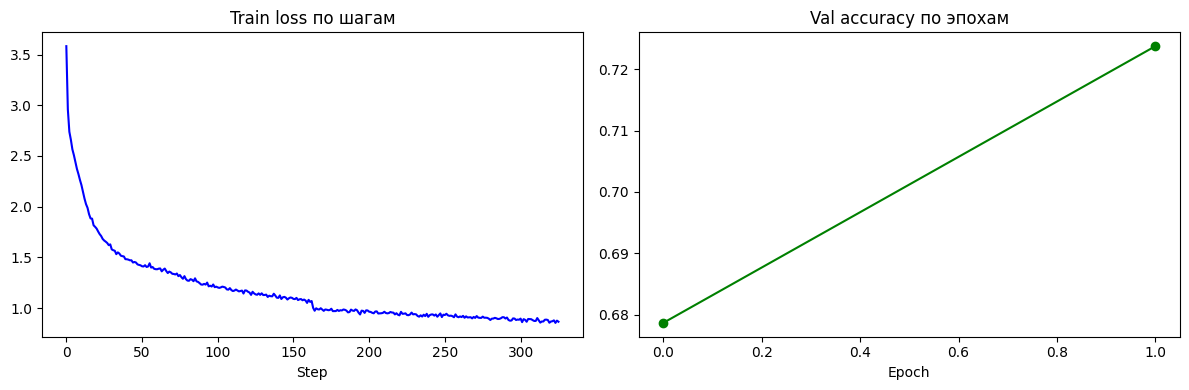

In [42]:
# trainer.evaluate() пропускаем — модель уже сохранена

history = trainer.state.log_history
train_loss = [h["loss"] for h in history if "loss" in h]
val_acc = [h["eval_accuracy"] for h in history if "eval_accuracy" in h]

print(f"Лучший val accuracy: {max(val_acc):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_loss, color="blue")
axes[0].set_title("Train loss по шагам")
axes[0].set_xlabel("Step")
axes[1].plot(val_acc, color="green", marker="o")
axes[1].set_title("Val accuracy по эпохам")
axes[1].set_xlabel("Epoch")
plt.tight_layout()
plt.show()

torch.cuda.empty_cache()

## Инференс

Предсказание позиций для test. Обязателен clamping: pred не должна превышать кол-во слов в оригинале.

In [44]:
def predict_positions(
    model,
    tokenizer,
    texts: list,
    original_texts: list,
    batch_size: int = 64,
    device: str = "cuda",
) -> list:
    """
    Предсказывает позицию пропущенного слова для каждого текста.

    Args:
        model: Обученная модель.
        tokenizer: Токенизатор.
        texts: Список текстов с пропуском.
        original_texts: Оригинальные тексты (с пропуском) для clamping.
        batch_size: Размер батча.
        device: Устройство.

    Returns:
        Список int — предсказанные позиции.
    """
    model.eval()
    model.to(device)
    predictions = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Inference"):
        batch = texts[i : i + batch_size]
        enc = tokenizer(
            batch,
            truncation=True,
            max_length=CFG["max_len"],
            padding=True,
            return_tensors="pt",
        )
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            out = model(**enc)
        preds = out.logits.argmax(dim=-1).cpu().tolist()
        orig_batch = original_texts[i : i + batch_size]
        for j, pred in enumerate(preds):
            n_words = len(orig_batch[j].split())
            clamped = min(int(pred), n_words)
            predictions.append(clamped)
    return predictions


def get_logits(model, tokenizer, texts, batch_size=64, device="cuda") -> np.ndarray:
    model.eval()
    model.to(device)
    all_logits = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Logits"):
        batch = texts[i : i + batch_size]
        enc = tokenizer(batch, truncation=True, max_length=CFG["max_len"], padding=True, return_tensors="pt")
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            out = model(**enc)
        all_logits.append(out.logits.cpu().numpy())
    return np.vstack(all_logits)


t0 = time.time()
texts_list = test_df["text"].tolist()

predictions = predict_positions(model, tokenizer, texts_list, texts_list, batch_size=64, device="cuda")
submission_path = CFG["submission_path"]

print(f"Время инференса: {time.time() - t0:.1f} сек")
print("Распределение предсказаний (top 15):")
print(pd.Series(predictions).value_counts().sort_index().head(15))

if use_ens:
    all_logits = []
    for seed in CFG["ensemble_seeds"]:
        model_dir = os.path.join(output_base, f"model_seed{seed}")
        m = AutoModelForSequenceClassification.from_pretrained(model_dir, num_labels=CFG["max_position"])
        all_logits.append(get_logits(m, tokenizer, texts_list, 64, "cuda"))
        del m
        torch.cuda.empty_cache()
    ensemble_logits = np.mean(all_logits, axis=0)
    raw_preds = np.argmax(ensemble_logits, axis=-1)
    predictions = [min(int(p), len(t.split())) for p, t in zip(raw_preds, texts_list)]
    submission_path = CFG["ensemble_submission_path"]
    print("Ансамбль: 2 модели")
else:
    predictions = predict_positions(model, tokenizer, texts_list, texts_list, batch_size=64, device="cuda")
    submission_path = CFG["submission_path"]

print(f"Время инференса: {time.time() - t0:.1f} сек")
print("Распределение предсказаний (top 15):")
print(pd.Series(predictions).value_counts().sort_index().head(15))

Inference:   0%|          | 0/235 [00:00<?, ?it/s]

Время инференса: 12.2 сек
Распределение предсказаний (top 15):
0     1733
1     1692
2     1582
3     1642
4     1418
5     1385
6      991
7      804
8      731
9      585
10     517
11     408
12     326
13     263
14     210
Name: count, dtype: int64


OSError: Repo id must be in the form 'repo_name' or 'namespace/repo_name': './output/model_seed42'. Use `repo_type` argument if needed.

## Submission

Формируем сабмит и сохраняем в CSV.

In [45]:
submission = pd.DataFrame({
    "ID": test_df["ID"],
    "missing_word_position": predictions,
})

assert len(submission) == len(test_df)
assert submission["missing_word_position"].min() >= 0
assert pd.api.types.is_integer_dtype(submission["missing_word_position"]), "missing_word_position должен быть integer"

save_path = CFG["ensemble_submission_path"] if (CFG.get("use_ensemble") and len(CFG.get("ensemble_seeds", [])) >= 2) else CFG["submission_path"]
submission.to_csv(save_path, index=False)
print(f"Saved: {save_path}")
print(submission.head(10).to_string(index=False))

Saved: ./output/submission_ensemble.csv
 ID  missing_word_position
  0                      5
  1                      8
  2                      7
  3                      4
  4                      2
  5                      0
  6                      0
  7                     12
  8                      2
  9                      4


## Ансамбль

Ансамбль 2 моделей (seeds 42 и 123) уже включён: при `use_ensemble=True` инференс усредняет logits и сохраняет в `submission_ensemble.csv`.

In [46]:
# Ансамбль выполняется в ячейке «Инференс» (get_logits + усреднение).
# Сабмит ансамбля сохраняется в CFG["ensemble_submission_path"].
print("Ансамбль:", "включён" if CFG["use_ensemble"] else "выключен")

Ансамбль: включён


## Итог

| Метрика | Значение |
|---------|----------|
| Val Accuracy | см. trainer.evaluate() |

### Советы по улучшению

- Увеличить `n_samples_per_sentence` до 5
- Ансамбль с другой моделью или другим seed
- `xlm-roberta-large` на Yandex Cloud GPU
- Span insertion scoring через MLM perplexity